In [1]:
import pandas as pd
df = pd.read_csv('feature_eng_df_final.csv')

In [2]:
# dropping credit score category since it already encoded as new column credit_score_numeric
df.drop('credit_score_category',axis=1,inplace=True)

In [3]:
#let's encode the binned age group column derived from age column in to ordinal encoder
df['age_group'].unique()
age_group_order = ['25-34','35-44', '45-54', '55-64']
from sklearn.preprocessing import OrdinalEncoder
age_group_encoder = OrdinalEncoder(categories=[age_group_order])
df['age_group'] = age_group_encoder.fit_transform(df[['age_group']])
print("after encoding df['age_group']",df['age_group'].unique())
df.drop('age',axis=1,inplace=True)

after encoding df['age_group'] [1. 3. 2. 0.]


In [4]:
#let encode binned employment experience type from year_of_employment column 
df['employment_tenure_category'].unique()
employment_order = ['Entry-level', 'Mid-level', 'Experienced']
emp_category_encoder = OrdinalEncoder(categories=[employment_order])
df['employment_tenure_category'] = emp_category_encoder.fit_transform(df[['employment_tenure_category']])
print("after encoding emp tenure category ",df['employment_tenure_category'].unique())
df.drop('years_of_employment',axis=1,inplace=True)

after encoding emp tenure category  [0. 1. 2.]


In [5]:
#let drop emi eligibility - another targer variable
df.drop('emi_eligibility',axis=1,inplace=True)

In [6]:
from sklearn.model_selection import train_test_split
X=df.drop(['max_monthly_emi'],axis=1)
y=df['max_monthly_emi']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(322243, 40)
(80561, 40)
(322243,)
(80561,)


In [8]:
training_columns = X_train.columns.tolist()

import joblib
joblib.dump(training_columns, "reg_training_columns.pkl")

['reg_training_columns.pkl']

In [7]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [8]:

from sklearn.model_selection import RandomizedSearchCV
import numpy as np
param_grid = {
    "n_estimators": [500, 800, 1200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.5, 1],
    "reg_lambda": [1, 1.5, 2]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring="r2",
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


In [9]:
best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [11]:
y_predict = best_xgb.predict(X_test)

In [13]:
mae_rf = mean_absolute_error(y_test, y_predict)
mse_rf = mean_squared_error(y_test, y_predict)
r2_rf = r2_score(y_test, y_predict)
mape_rf = mean_absolute_percentage_error(y_test, y_predict) * 100

print("XGB Regressor Results:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R2:", r2_rf)
print("MAPE:", mape_rf)

XGB Regressor Results:
MAE: 0.19984094631739932
MSE: 0.08480863113223741
R2: 0.9542912505492295
MAPE: 2.7384704047798984


In [14]:
x_predict = best_xgb.predict(X_train)
x_mae = mean_absolute_error(y_train,x_predict)
print("mean absolute error--",x_mae)
x_mse = mean_squared_error(y_train,x_predict)
print("mean square error--",x_mse)
r2_scr = r2_score(y_train,x_predict)
print("r2 score",r2_scr)
mape = mean_absolute_percentage_error(y_train, x_predict)
print("MAPE:", mape * 100)

mean absolute error-- 0.1944441111483863
mean square error-- 0.07860493809324356
r2 score 0.9577467622523881
MAPE: 2.659702848274805


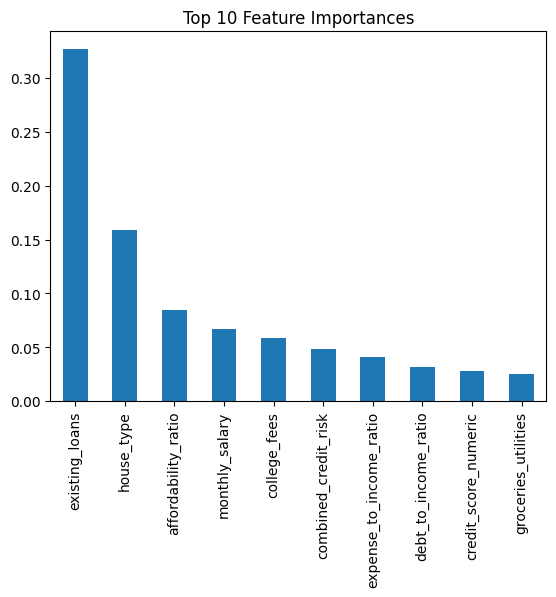

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importances.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances")
plt.show() 

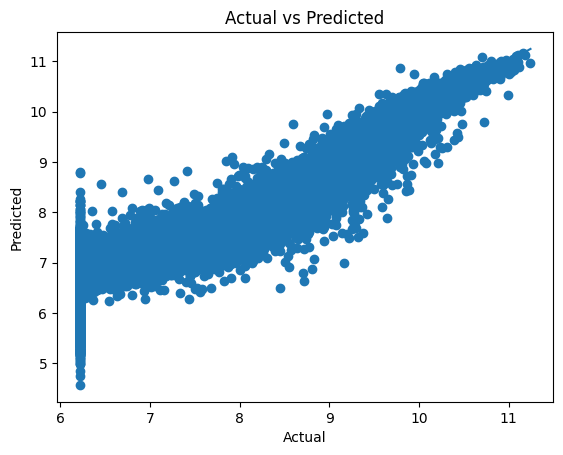

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

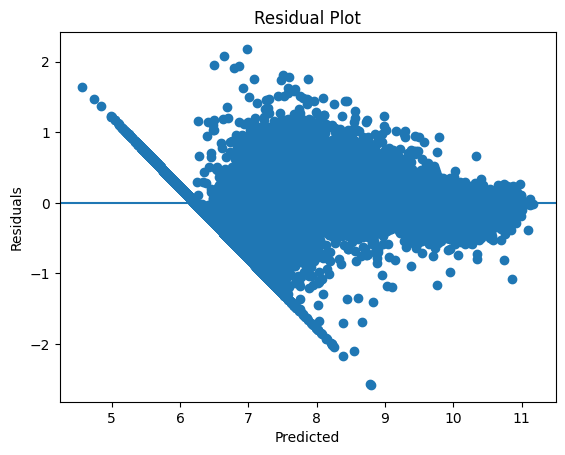

In [15]:
residuals = y_test - y_pred_rf

plt.figure()
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

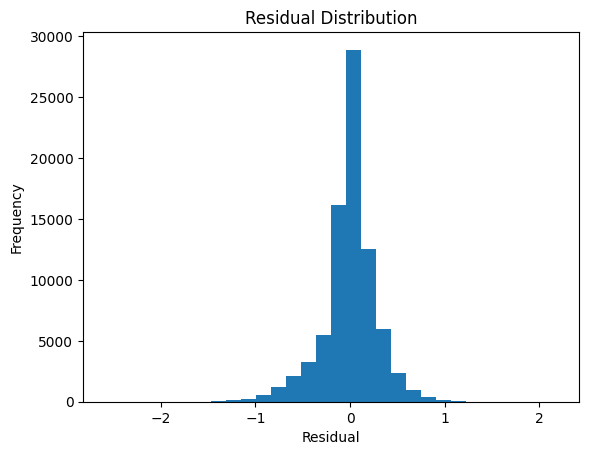

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

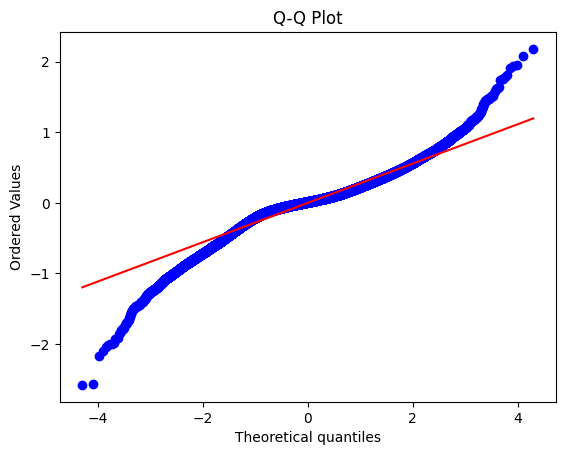

In [17]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [15]:
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

mlflow.set_experiment("Max Monthly EMI Prediction XGBoost Regressor experiment")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
# Start an MLflow run
with mlflow.start_run(run_name="xgboost_High_Volume_Run"):
    
    # 1. Log RF Parameters (Trees, Depth, etc.)
    # This captures n_estimators, max_depth, etc., automatically
    mlflow.log_params(best_xgb.get_params())

    # 2. Calculate and Log Metrics
    mae = mean_absolute_error(y_test, y_predict)
    mse = mean_squared_error(y_test, y_predict)
    r2_scr = r2_score(y_test, y_predict)
    mape = mean_absolute_percentage_error(y_test, y_predict)

    mlflow.log_metrics({
        "mae": mae,
        "mse": mse,
        "r2_score": r2_scr,
        "mape": mape
    })

    # 3. Feature Importance Plot (Crucial for RF)
    importances = best_xgb.feature_importances_
    indices = np.argsort(importances)[-15:]  # Top 15 features
    
    fig_imp = plt.figure(figsize=(10, 7))
    plt.title('Top 15 Feature Importances')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
    plt.xlabel('Relative Importance')
    mlflow.log_figure(fig_imp, "plots/feature_importance.png")
    plt.close(fig_imp)

    # 4. Actual vs Predicted
    fig_res = plt.figure()
    plt.scatter(y_test, y_predict, alpha=0.1) # Lower alpha for 400k points to see density
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted")
    mlflow.log_figure(fig_res, "plots/actual_vs_predicted.png")
    plt.close(fig_res)

    # --- 2. Residual Plot ---
    # Used to check for heteroscedasticity (patterns in error)
    fig2 = plt.figure(figsize=(8, 6))
    residuals = y_test - y_predict
    plt.scatter(y_predict, residuals, alpha=0.3, color='orange')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    mlflow.log_figure(fig2, "plots/residual_plot.png")
    plt.close(fig2)

    
    # 5. Residual Distribution (Checking for Normality)
    
    fig_hist = plt.figure()
    plt.hist(residuals, bins=50)
    plt.title("Residual Distribution")
    mlflow.log_figure(fig_hist, "plots/residual_dist.png")
    plt.close(fig_hist)

    # 6. Log the model artifact
    mlflow.sklearn.log_model(best_xgb, "xgbr_model")

    print("Logged metrics and plots to MLflow (Skipped Learning Curve for speed).")

2026/02/27 22:11:03 INFO mlflow.tracking.fluent: Experiment with name 'Max Monthly EMI Prediction XGBoost Regressor experiment' does not exist. Creating a new experiment.
2026/02/27 22:11:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\RAM\miniconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Logged metrics and plots to MLflow (Skipped Learning Curve for speed).
🏃 View run xgboost_High_Volume_Run at: http://127.0.0.1:5000/#/experiments/11/runs/279a488b0aae464caf41673d958efd39
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/11
